## **PERTEMUAN 11: UNSUPERVISED LEARNING: CLUSTERING (K-MEANS & HIERARCHICAL)**
---
## **Aktivitas Hands-on: Segmentasi Pelanggan**
---
### NAMA  : SHERLY EKA WINDIANI
### NIM   : 240401010222
### KELAS : IF403


Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


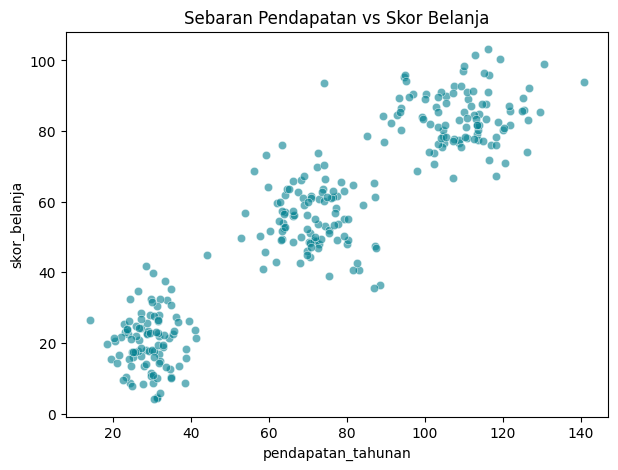

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2)) # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2)) # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6, color='#028090')
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


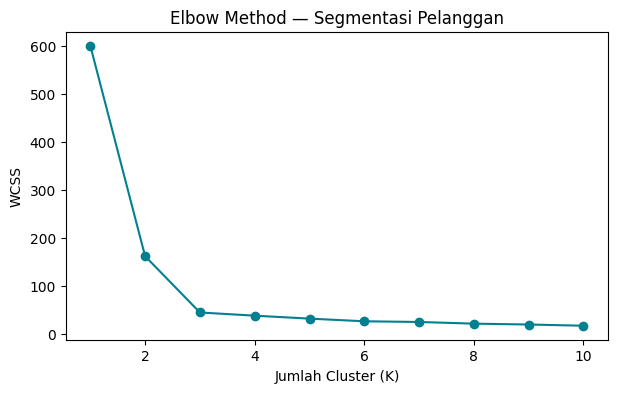

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()

### Interpretasi Grafik Elbow:
- Kurva WCSS mulai mengalami pelandaian yang signifikan (membentuk siku/elbow) tepat pada **K = 3**.
- Hasil ini sangat konsisten dan sesuai dengan jumlah kelompok tersembunyi (*ground truth*) yang digunakan saat pembuatan dataset sintetis di awal.

In [ ]:
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print("\nRata-rata per Cluster:")
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir : 44.556
Silhouette Score: 0.695

Rata-rata per Cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


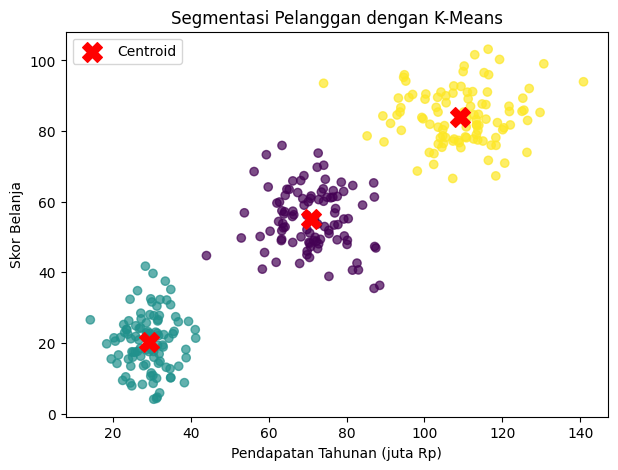

In [ ]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

### Interpretasi Karakteristik Tiap Segmen Pelanggan:
- **Cluster 0 (Hemat):** Memiliki pendapatan tahunan rendah dan skor belanja yang rendah.
- **Cluster 1 (Menengah):** Memiliki pendapatan tahunan dan skor belanja pada tingkat moderat/menengah.
- **Cluster 2 (Boros/Premium):** Memiliki pendapatan tahunan yang tinggi serta skor belanja yang tinggi.

### Kesimpulan

Pada pertemuan ini, kita telah mempelajari dasar-dasar Unsupervised Learning, dengan fokus utama pada teknik Clustering untuk menemukan pola atau struktur tersembunyi di dalam data tanpa label.

**Temuan Utama:**
* Clustering: Metode untuk mengelompokkan data ke dalam beberapa kelompok (cluster) berdasarkan kemiripan karakteristik, yang berbeda dari pendekatan Supervised Learning sebelumnya.
* K-Means Clustering: Algoritma partitional yang bekerja secara iteratif untuk meminimalkan Within-Cluster Sum of Squares (WCSS) dengan menempatkan data ke dalam K buah centroid.
* Hierarchical Clustering: Pendekatan bertingkat yang menghasilkan struktur pohon (dendrogram), memungkinkan analisis hubungan antar data secara lebih mendalam melalui metode linkage (seperti Ward atau Average).
* Metode Elbow: Teknik krusial untuk menentukan jumlah cluster (K) yang optimal dengan mengamati titik di mana penurunan WCSS mulai melambat secara signifikan.

**Keterbatasan & Pertanyaan:**
* K-Means sangat sensitif terhadap inisialisasi centroid awal dan nilai K yang ditentukan di awal, serta memiliki kesulitan dalam menangani bentuk cluster yang tidak bulat atau kompleks.
* Bagaimana cara terbaik menentukan K optimal jika data yang dimiliki memiliki noise yang tinggi atau outlier yang ekstrem?
* Selain Silhouette Score, apakah ada metrik lain yang lebih robust untuk mengevaluasi kualitas cluster pada dataset dengan dimensi fitur yang sangat besar?